# DEMAND FORECASTING WAIKATO

Visit demand forecasting with the collaboration of Waikato "Te ipu o te mahara" Artificial intelligence institute. 

## Environment Requirements (Conda)
Install the environment dependencies from requirement file in folder.

In [1]:
import importlib
import evaluation_plot_utils
import data_preparation
importlib.reload(evaluation_plot_utils)

<module 'evaluation_plot_utils' from 'C:\\Users\\34648\\OneDrive - Generalitat de Catalunya\\Escriptori\\waikato\\evaluation_plot_utils.py'>

In [2]:
#!/usr/bin/env python
# coding: utf-8
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns


from collections import deque
from functools import partial
import getopt
import sys
import os
import time
import math
import pickle
from sklearn.preprocessing import MinMaxScaler

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import mean_squared_error, mean_absolute_error

# depending on the distribution, you might want to change the import.
from tensorflow.keras.optimizers import Adam
#from keras.optimizers.legacy import Adam

## Data upload

Data of visit demand forecasting AP in Catalonia Spain (years 2010-2020). 

In [ ]:
# RAW DATA --------------------------------------------------------------
df = pd.read_csv('J:/longitudinalitat_DIAGNOSTICS_GROUPED.csv', index_col=0)
df['COV-19'] = df["B34"]+df["U07"]   # join cov19 codes
df = df.drop(['B34', 'U07'], axis=1)

df.index = pd.to_datetime(df.index)
d = pd.to_datetime('2000-01-01')
mask = df.index < d
df = df.loc[~mask]

d = pd.to_datetime('2010-01-01')
mask = df.index < d
df = df.loc[~mask]

df["Overall"] = df.iloc[:, 1:].sum(axis=1)
display(df)

,A00,A01,A02,A03,A04,A05,A06,A07,A08,A09,...,Z92,Z93,Z94,Z95,Z96,Z97,Z98,Z99,COV-19,Overall
2010-01-01,0,1,0,0,2,0,1,0,24,132,...,1,7,7,59,121,7,28,10,35,20817
2010-01-02,0,0,1,0,1,0,0,0,43,272,...,0,0,2,0,3,1,4,1,96,5004
2010-01-03,0,0,0,0,0,0,0,0,36,211,...,0,0,0,0,0,0,1,0,63,3306
2010-01-04,0,0,3,0,1,3,0,3,185,956,...,9,1,1,11,8,1,28,2,286,23346
2010-01-05,0,0,0,0,4,0,0,0,88,511,...,3,1,2,7,9,2,25,0,136,17386
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-06-26,0,0,0,0,0,1,0,1,27,216,...,1,0,5,5,2,0,2,0,648,11982
2021-06-27,0,0,1,0,3,1,0,0,22,193,...,0,0,3,2,1,1,0,0,822,11086
2021-06-28,0,0,3,0,8,10,0,2,54,651,...,8,4,5,21,22,3,18,4,2612,53335
2021-06-29,0,0,0,0,3,3,1,5,52,509,...,13,2,6,15,21,13,14,10,2395,50013


Plot of example 10 diagnoses during period 2010-2022 (covid included)

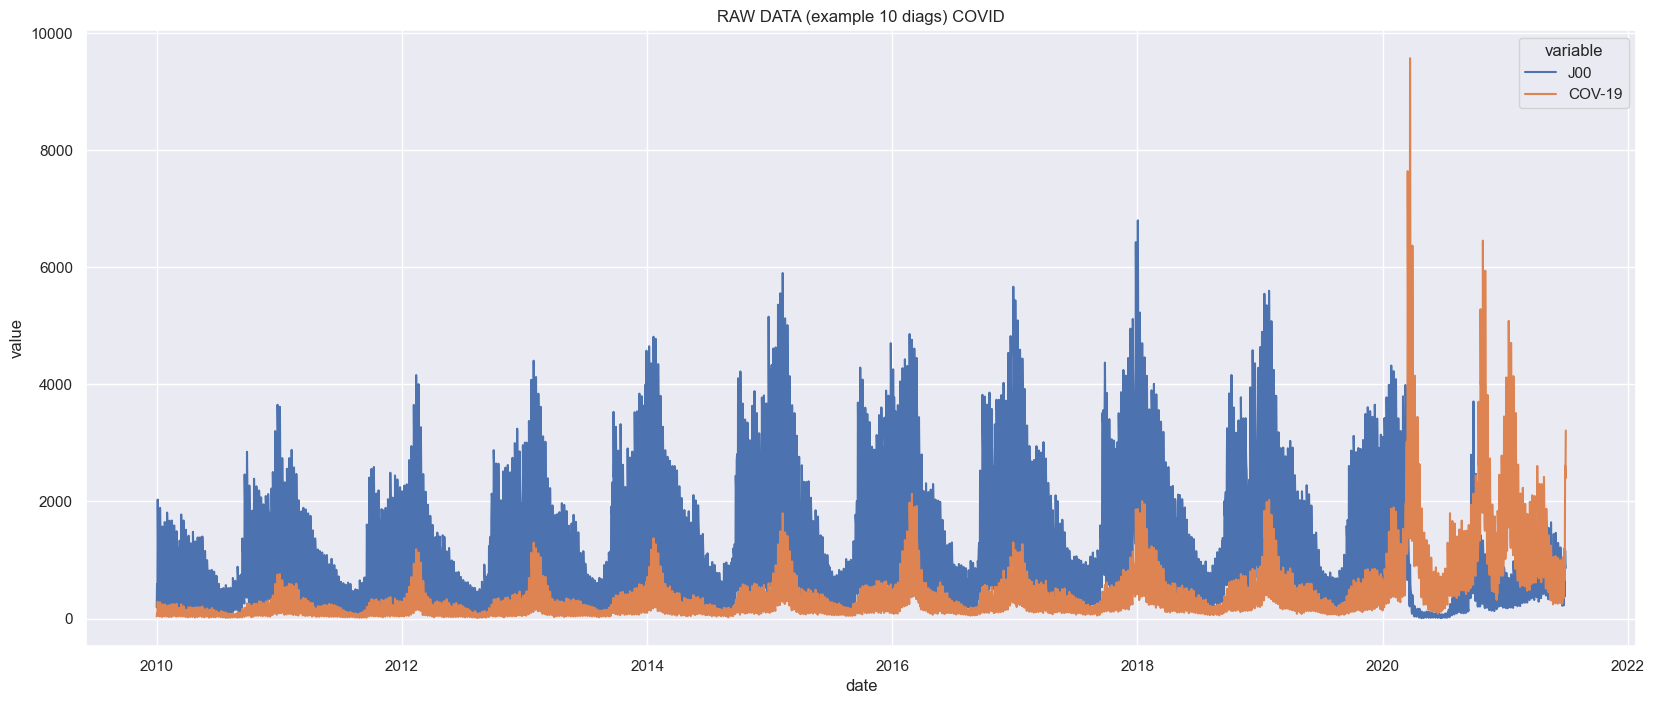

In [4]:
# plot example 10 diags -------------------------
def plot_example(df,title):
    # PLOT RAW DATA (example 10 diags)
    dff = df
    dff["date"] = dff.index
    dff = dff[['J00','COV-19','date']]
    sns.set(rc={'figure.figsize':(20,8)})
    sns.lineplot(data=dff.replace('nan', float('nan')).melt(id_vars=['date']),x='date', y='value', hue='variable').set(title=title)
    
plot_example(df,"RAW DATA (example 10 diags) COVID")

In [5]:
df

,A00,A01,A02,A03,A04,A05,A06,A07,A08,A09,...,Z93,Z94,Z95,Z96,Z97,Z98,Z99,COV-19,Overall,date
2010-01-01,0,1,0,0,2,0,1,0,24,132,...,7,7,59,121,7,28,10,35,20817,2010-01-01
2010-01-02,0,0,1,0,1,0,0,0,43,272,...,0,2,0,3,1,4,1,96,5004,2010-01-02
2010-01-03,0,0,0,0,0,0,0,0,36,211,...,0,0,0,0,0,1,0,63,3306,2010-01-03
2010-01-04,0,0,3,0,1,3,0,3,185,956,...,1,1,11,8,1,28,2,286,23346,2010-01-04
2010-01-05,0,0,0,0,4,0,0,0,88,511,...,1,2,7,9,2,25,0,136,17386,2010-01-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-06-26,0,0,0,0,0,1,0,1,27,216,...,0,5,5,2,0,2,0,648,11982,2021-06-26
2021-06-27,0,0,1,0,3,1,0,0,22,193,...,0,3,2,1,1,0,0,822,11086,2021-06-27
2021-06-28,0,0,3,0,8,10,0,2,54,651,...,4,5,21,22,3,18,4,2612,53335,2021-06-28
2021-06-29,0,0,0,0,3,3,1,5,52,509,...,2,6,15,21,13,14,10,2395,50013,2021-06-29


In [6]:
# Define function for train-test split
def split_train_test(df, split_ratio=0.8):
    """
    Splits a dataframe into train and test sets using the given split ratio.

    Parameters:
    df (pd.DataFrame): The input dataframe to split.
    split_ratio (float): The fraction of data to be used for training (default is 0.8).

    Returns:
    train_df (pd.DataFrame): Training dataset.
    test_df (pd.DataFrame): Testing dataset.
    """
    split_idx = int(len(df) * split_ratio)  # Compute split index
    train_df = df.iloc[:split_idx].reset_index(drop=True)
    test_df = df.iloc[split_idx:].reset_index(drop=True)
    
    return train_df, test_df


In [7]:
# no pandemic 

#d = pd.to_datetime('2020-01-01')
#mask = df.index > d
#df = df.loc[~mask]


In [8]:
code = "T14"

# Create a new DataFrame with timestamp and target columns
transformed_df = df[["date", code]].rename(columns={"date": "timestamp", code: code})
transformed_df["timestamp"] = pd.to_datetime(transformed_df["timestamp"])
transformed_df.reset_index(drop=True, inplace=True)

# Apply Min-Max Scaling (0 to 1) only to the "target" column
scaler = MinMaxScaler(feature_range=(0, 1))
transformed_df[code] = scaler.fit_transform(transformed_df[[code]]) 

# Apply function to split data
train_df, test_df = split_train_test(transformed_df)
print(train_df.info())
print(test_df.info())

# Save train and test files
train_file_path = f"{code}_train_example.csv"
test_file_path = f"{code}_test_example.csv"

train_df.to_csv(train_file_path, index=False)
test_df.to_csv(test_file_path, index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3359 entries, 0 to 3358
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  3359 non-null   datetime64[ns]
 1   T14        3359 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 52.6 KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  840 non-null    datetime64[ns]
 1   T14        840 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 13.2 KB
None


In [9]:
def evaluate_model(model, X_test, Y_test, sliding_window=10):
    """
    Evaluate the model using a sliding window approach.

    Args:
        model: Trained Keras model.
        X_test: Test input data (shape: (samples, lookback, 1)).
        Y_test: True future values (shape: (samples, n_pred)).
        sliding_window: Number of test samples to slide over.
    
    Returns:
        Plots the MSE, MAE, and Loss over time.
    """

    mse_list = []
    mae_list = []
    loss_list = []

    num_samples = len(X_test) - sliding_window + 1  # Number of sliding steps

    for i in range(num_samples):
        X_window = X_test[i : i + sliding_window]  # Get sliding window input
        Y_window_true = Y_test[i : i + sliding_window]  # True values

        # Predict using the model
        Y_window_pred = model.predict(X_window, verbose=0)

        # Compute metrics
        mse = mean_squared_error(Y_window_true, Y_window_pred)
        mae = mean_absolute_error(Y_window_true, Y_window_pred)
        loss = np.mean(np.abs(Y_window_true - Y_window_pred))  # Approximate loss (MAE)

        # Store metrics
        mse_list.append(mse)
        mae_list.append(mae)
        loss_list.append(loss)

    # Plot results
    plt.figure(figsize=(15, 5))

    # Plot MSE
    plt.subplot(3, 1, 1)
    plt.plot(mse_list, label="MSE")
    plt.xlabel("Sliding Window Step")
    plt.ylabel("MSE")
    plt.title("Mean Squared Error (MSE)")
    plt.legend()

    # Plot MAE
    plt.subplot(3, 1, 2)
    plt.plot(mae_list, label="MAE", color="orange")
    plt.xlabel("Sliding Window Step")
    plt.ylabel("MAE")
    plt.title("Mean Absolute Error (MAE)")
    plt.legend()

    # Plot Loss
    plt.subplot(3, 1, 3)
    plt.plot(loss_list, label="Loss", color="red")
    plt.xlabel("Sliding Window Step")
    plt.ylabel("Loss")
    plt.title("Loss Over Sliding Window")
    plt.legend()

    plt.tight_layout()
    plt.show()

### Definition of transformer and models

##### Transformer encoder layers definition

This structure is similar to the Transformer encoder blocks used in BERT, GPT, and Vision Transformers (ViTs). Instead of the usual dense feed-forward layers, 1D convolutions are used, which can be beneficial for sequence data processing.

Function Arguments:

- inputs: The input tensor to the encoder block.
- head_size: The dimension of each attention head in the multi-head self-attention mechanism.
- num_heads: The number of attention heads.
- ff_dim: The number of units in the feed-forward layer.
- dropout: Dropout rate (default is 0), which helps prevent overfitting.

In [10]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Normalization and Attention
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)                  # to imputs to stabilize training
    x = layers.MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)   # self attention to normalized input 
    x = layers.Dropout(dropout)(x) # (dropout to reduce overfitting)
    res = x + inputs               # attention output added to original inputs

    # Feed Forward Part
    x = layers.LayerNormalization(epsilon=1e-6)(res)                       # again after resid connection
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="tanh")(x) # point-wise convol.: Expands feature dim to ff_dim using tanh activ
    x = layers.Dropout(dropout)(x)                                         # dropout again
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)          # reduces feature dim back to match input size
    return x + res

##### GENERAL MODEL DEFINITION

Use Case

This model is well-suited for time series forecasting, sequence classification, or regression tasks. Instead of using traditional RNNs (LSTMs, GRUs), it leverages self-attention to capture long-range dependencies in sequential data.

Function Arguments

- input_shape: Shape of the input data (e.g., (sequence_length, features) for time series data).
- head_size: The size of each attention head in the multi-head attention mechanism.
- num_heads: Number of attention heads in the self-attention mechanism.
- ff_dim: Number of units in the feed-forward network of each Transformer encoder block.
- num_transformer_blocks: Number of Transformer encoder blocks in the model.
- mlp_units: A list defining the units of fully connected (MLP) layers after the Transformer blocks.
- dropout: Dropout rate applied within Transformer blocks.
- mlp_dropout: Dropout rate applied to the MLP layers.
- n_pred: Number of output predictions (default is 1, for regression or binary classification).

In [11]:
def build_model(input_shape, head_size, num_heads, ff_dim, num_transformer_blocks, mlp_units, dropout=0, mlp_dropout=0, n_pred=1):
    inputs = keras.Input(shape=input_shape) #defines input tensor
    x = inputs 
    for _ in range(num_transformer_blocks): #apply num_transformer_blocks transformer encoder layers seq.
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout) #uses previous defined trans_encoder layer

    x = layers.GlobalAveragePooling1D(data_format="channels_first")(x) # reduces seq dimension (timesteps) averaging for each fature channel
    for dim in mlp_units:                                              # multi layer perceptron (dropout to avoid overfitting)
        x = layers.Dense(dim, activation="tanh")(x)
        x = layers.Dropout(mlp_dropout)(x)
    outputs = layers.Dense(n_pred)(x)
    return keras.Model(inputs, outputs)

##### Custom cosine decay learning rate schedule

- The warmup phase (first 20 steps) shows a linear increase from initial_lr (0.0001) to max_lr (0.001).
- The cosine decay phase (after 20 steps) smoothly decreases the learning rate from max_lr to min_lr (0.00001).
- This schedule ensures stable training by gradually increasing the learning rate before decaying it smoothly.


In [12]:
# defaults to 50 epochs total and 20 warmup steps
class CustomCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, initial_lr=1e-4, max_lr=1e-3, min_lr=1e-5, warmup_steps=20, total_steps=50):
        self.initial_lr = initial_lr  # Starting learning rate (0.01)
        self.max_lr = max_lr          # Maximum learning rate (0.1)
        self.min_lr = min_lr          # Final learning rate (0.0001)
        self.warmup_steps = warmup_steps  # Number of warmup steps to reach max_lr
        self.total_steps = total_steps    # Total number of steps (decay after warmup)

    def __call__(self, step):
        # Warm-up phase: linearly increase to max_lr
        if step < self.warmup_steps:
            return self.initial_lr + (self.max_lr - self.initial_lr) * (step / self.warmup_steps)

        # Cosine decay phase after warmup
        decay_steps = self.total_steps - self.warmup_steps
        step_after_warmup = step - self.warmup_steps
        cosine_decay = 0.5 * (1 + math.cos(math.pi * step_after_warmup / decay_steps))
        decayed = (self.max_lr - self.min_lr) * cosine_decay + self.min_lr
        return decayed

##### TRAIN MODEL

This function, train_given_model_and_data, is designed to train a Keras model while providing additional functionalities such as saving the model, handling memory usage, logging training history, and using early stopping. Below is a detailed breakdown of its structure and purpose.

- model: The Keras model to be trained.
- X: Input data.
- Y: Target labels.
- batch_size: Size of mini-batches (default 1024).
- model_name: Name of the model file for saving/loading.
- epochs: Number of training epochs (default 100).
- save_history: Whether to save the training history (default False).
- save_model: Whether to save the trained model (default True).
- save_memory: Whether to log memory usage (default True).
- shuffle: Whether to shuffle training data before each epoch (default False).
- callbacks: List of Keras callbacks (default None, but adds early stopping if not provided).

In [13]:
def train_given_model_and_data(model, X, Y, batch_size=1024, model_name=None, epochs=100, save_history=False, save_model=True, save_memory=True, shuffle=False, callbacks=None):
    if save_memory: #configure GPU memory growth
        # prepare for measuring memory
        gpus = tf.config.experimental.list_physical_devices('GPU')
        if gpus:
            try:
                for gpu in gpus:
                    tf.config.experimental.set_memory_growth(gpu, True)
            except RuntimeError as e:
                print(e)
    if callbacks is None: # define callbacks (If no callbacks are provided, it automatically enables Early Stopping)
        early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=5, restore_best_weights=True)
        callbacks = [early_stop]

    if not os.path.exists(f'{model_name}'): #check if model exist and run if not
        history = model.fit(x=X, 
                            y=Y, 
                            batch_size=batch_size,  # batch gradient descent (batch size 1024)
                            epochs=epochs, 
                            shuffle=shuffle,        # Allows shuffling
                            validation_split=0.3,   # 30% data for validation
                            callbacks=callbacks)
    else:
        print(f"model {model_name} already exists")
        return

    if model_name is None:
        model_name = "testing"

    if save_history: # save training history
        with open(f'{model_name}_history.pkl', 'wb') as file_pi:
            pickle.dump(history.history, file_pi)
    
    if save_model and epochs > 1: # save model
        model.save(model_name)
        
    if save_memory: # log memory usage (optional)
        # save memory usave
        # Get memory information
        memory_info = tf.config.experimental.get_memory_info('GPU:0')
        with open('memory.csv', 'a') as resultcsv:
            resultcsv.write(f"{model_name},{memory_info['peak']},train\n")
        print(f"Current memory usage: {memory_info['current'] / (1024**2)} MB")
        print(f"Peak memory usage: {memory_info['peak'] / (1024**2)} MB")

##### PREPARE DATA

The function prepare_data loads a CSV file, processes it into input (X) and output (Y) arrays, and reshapes the data for training models that use time series sequences (such as RNNs, LSTMs, Transformers, etc.). Below is a detailed breakdown.

In [15]:
#def prepare_data(csv_file, lookback, debug=False):
#    df = pd.read_csv(csv_file)
#    df.info()
#    X = np.array(df.iloc[:, :-1])
#    Y = np.array(df.iloc[:, -1].values)
#    X = X.reshape(-1, lookback, 1)
#    Y = Y.reshape(-1, 1)
#    if debug:
#        print('X', X.shape, type(X),'\nY',  Y.shape,  type(Y))
#    return X, Y

### PARAMETER DEFINITION

In [16]:
# Set default values ...............................................................
forecast=7      # number of future time steps the model will predict (predict horizon)
lookback=7     # how many past time steps the model uses as input  (input seq length)

#Transformer model .................................................................
head_size=2              # dimensions of each attention head(If you have num_heads=2, 
                         #     attention 2 * head_size = 4 dimensions.)
num_heads=2              # number attention head (More headsimprove ability to focus 
                         #     on different aspects but increase computational cost.)
num_transformer_blocks=2 # n transformer layers (More blocks can improve the model's 
                         #     capacity but may lead to overfitting.)
ff_dim=8                 # dimensionality feed-forward layer  (more increases capacity but adds cost)

# Multi-Layer Perceptron (MLP) Parameters ...........................................
mlp_units=32     # n neurons fully connected feed forward network (MLP)
mlp_dropout=0.25 # dropout rate MLP layers to prevent overfitting (% neurons randomly dropper durinhg training)

# General Regularization Parameters .................................................
dropout=0.5

# Optimization and Training Parameters ..............................................
learning_rate = 0.001  # step size for gradient updates during training.( more speeds up but cause instabiliy)
epochs=100             # max number of times to train
early_stop_patience=15 # if not improvement


In [17]:
# The commented-out code suggests an optional command-line interface for changing hyperparameters.

# # Get command line arguments
# opts, args = getopt.getopt(sys.argv[1:], "", ["ff=", "lb=", "lr=", "ep=", "tr="])
# reduced_network = False

# # Parse command line arguments
# for opt, arg in opts:
#         if opt == "--lb":
#                 lookback_hours = int(arg)
#         elif opt == "--lr":
#                 learning_rate = float(arg)
#         elif opt == "--ff":
#                 ff_dim = int(arg)
#         elif opt == "--ep":
#                 epochs = int(arg)
#         elif opt == "--tr":
#                 temporal_res = int(arg)
#                 records_per_hour = 60 / temporal_res
# if temporal_res != 5:
#         input_directory = f'./exper-downsample/'
#         interp_files_dir = f'./interp-downsample/'

##### RUN EXPERIMENT

In [15]:
start_time = time.perf_counter()
input_directory = f'C:/Users/34648/OneDrive - Generalitat de Catalunya/Escriptori/waikato/diagnostic_data' # define data dir
batchSize=16               # how many samples processing in parallel during training
shuffle=False              # randomize order of training data??


start_time = time.perf_counter()

csvFile = f'{input_directory}/{code}_train_example.csv'

# prepare X and Y arrays
X, Y = data_preparation.prepare_data(f'{input_directory}/{code}_train_example.csv', lookback, forecast, debug=True, univariate =True)

finish_preparing = time.perf_counter()
time_data_preparation = finish_preparing - start_time
print("finished preparing data, time spent:",time_data_preparation)

NameError: name 'lookback' is not defined

In [ ]:
print(X.shape, Y.shape)

##### Build model

In [ ]:
# declare model
model = build_model(
    (lookback,1),
    head_size=head_size,
    num_heads=num_heads,
    ff_dim=ff_dim,
    num_transformer_blocks=num_transformer_blocks,
    mlp_units=[mlp_units],
    mlp_dropout=mlp_dropout,
    dropout=dropout,
    n_pred=forecast#+1
)

#model.summary()

##### Train

In [ ]:
# Create the custom learning rate schedule
LR_init=learning_rate
LR_min=LR_init*10
LR_max=LR_init*10*10
scheduler = CustomCosineDecay(initial_lr=LR_init, max_lr=LR_max, min_lr=LR_min, warmup_steps=epochs/5, total_steps=epochs)

callbacks = [
    tf.keras.callbacks.LearningRateScheduler(
        scheduler),
    tf.keras.callbacks.EarlyStopping(
        patience=early_stop_patience,
        monitor='val_loss',
        mode='min',
        restore_best_weights=True)]


model.compile(loss='MSE', metrics=['mae', 'mse'], optimizer=Adam())

In [ ]:
# train model
model_name = f'{code}_example_transformer_{forecast}fh_{ff_dim}ff_{lookback}lb_{learning_rate}initlr'
callbacks = [tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=early_stop_patience, restore_best_weights=True)]
train_given_model_and_data(model, X, Y, model_name=model_name, epochs=epochs, save_model=True, save_memory=False, callbacks=callbacks)

Metodology to test and generate several models for different lookback and forecast horizon periods.

In [26]:
# Code defincition (assuming train and test already computed)
code = 'M54_NOPAND'

# Set default values
forecast= [1,7,14,30,60,182,365]      
lookback= [1,7,14,30,60,182,365]

#Transformer model
head_size=2              # dimensions of each attention head(If you have num_heads=2, attention 2 * head_size = 4 dimensions.)
num_heads=2              # number attention head (More headsimprove ability to focus on different aspects but increase computational cost.)
num_transformer_blocks=2 # n transformer layers (More blocks can improve the model's capacity but may lead to overfitting.)
ff_dim=8                 # dimensionality feed-forward layer  (more increases capacity but adds cost)

# Multi-Layer Perceptron (MLP) Parameters
mlp_units=32     # n neurons fully connected feed forward network (MLP)
mlp_dropout=0.25 # dropout rate MLP layers to prevent overfitting (% neurons randomly dropper durinhg training)

# General Regularization Parameters
dropout=0.5

# Optimization and Training Parameters
learning_rate = 0.001  # step size for gradient updates during training.( more speeds up but cause instabiliy)
epochs=100             # max number of times to train
early_stop_patience=15 # if not improvement

input_directory = f'C:/Users/34648/OneDrive - Generalitat de Catalunya/Escriptori/waikato/diagnostic_data' # define data dir
batchSize=16               # how many samples processing in parallel during training
shuffle=False              # randomize order of training data??

LR_init=learning_rate
LR_min=LR_init*10
LR_max=LR_init*10*10

# prior to start (the model search if the model is already computed on the same folder it is present. If you have
# models already computed move them to the scripts folder.)

for lb in lookback:

    csvFile = f'{input_directory}/{code}_train_example.csv'
    
    for fh in forecast:
        
        # prepare X and Y arrays
        X, Y = data_preparation.prepare_data(f'{input_directory}/{code}_train_example.csv', lb, fh, debug=True, univariate =True)
        
        start_time = time.perf_counter()
        # declare model
        model = build_model(
            (lb,1),
            head_size=head_size,
            num_heads=num_heads,
            ff_dim=ff_dim,
            num_transformer_blocks=num_transformer_blocks,
            mlp_units=[mlp_units],
            mlp_dropout=mlp_dropout,
            dropout=dropout,
            n_pred=fh#+1
        )
        
        # Create the custom learning rate schedule
        scheduler = CustomCosineDecay(initial_lr=LR_init, max_lr=LR_max, min_lr=LR_min, warmup_steps=epochs/5, total_steps=epochs)

        callbacks = [
            tf.keras.callbacks.LearningRateScheduler(scheduler),
            tf.keras.callbacks.EarlyStopping(
                patience=early_stop_patience,
                monitor='val_loss',
                mode='min',
                restore_best_weights=True)]


        model.compile(loss='MSE', metrics=['mae', 'mse'], optimizer=Adam())
        
        # train model
        model_name = f'{code}_example_transformer_{fh}fh_{ff_dim}ff_{lb}lb_{learning_rate}initlr'
        callbacks = [tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=early_stop_patience, restore_best_weights=True)]
        train_given_model_and_data(model, X, Y, model_name=model_name, epochs=epochs, save_model=True, save_memory=False, callbacks=callbacks)
        
        finish_preparing = time.perf_counter()
        time_data_preparation = finish_preparing - start_time
        print("finished modelling, time spent:",time_data_preparation)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2922 entries, 0 to 2921
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  2922 non-null   object 
 1   M54        2922 non-null   float64
dtypes: float64(1), object(1)
memory usage: 45.8+ KB
Processed Data Shapes: X=(2921, 1, 1), Y=(2921, 1)
model M54_NOPAND_example_transformer_1fh_8ff_1lb_0.001initlr already exists
finished modelling, time spent: 0.13515910000000986
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2922 entries, 0 to 2921
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  2922 non-null   object 
 1   M54        2922 non-null   float64
dtypes: float64(1), object(1)
memory usage: 45.8+ KB
Processed Data Shapes: X=(2915, 1, 1), Y=(2915, 7)
model M54_NOPAND_example_transformer_7fh_8ff_1lb_0.001initlr already exists
finished modelling, time spent: 0.14009219999996958
<cla

Exception ignored in: <function ScopedTFGraph.__del__ at 0x0000021D48617B80>
Traceback (most recent call last):
  File "D:\anaconda\lib\site-packages\tensorflow\python\framework\c_api_util.py", line 54, in __del__
    self.deleter(self.graph)
AttributeError: deleter


model M54_NOPAND_example_transformer_14fh_8ff_1lb_0.001initlr already exists
finished modelling, time spent: 3.20421859999999
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2922 entries, 0 to 2921
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  2922 non-null   object 
 1   M54        2922 non-null   float64
dtypes: float64(1), object(1)
memory usage: 45.8+ KB
Processed Data Shapes: X=(2892, 1, 1), Y=(2892, 30)
model M54_NOPAND_example_transformer_30fh_8ff_1lb_0.001initlr already exists
finished modelling, time spent: 0.15778040000003557
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2922 entries, 0 to 2921
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  2922 non-null   object 
 1   M54        2922 non-null   float64
dtypes: float64(1), object(1)
memory usage: 45.8+ KB
Processed Data Shapes: X=(2862, 1, 1), Y=(2862, 60)
mod

model M54_NOPAND_example_transformer_365fh_8ff_14lb_0.001initlr already exists
finished modelling, time spent: 0.14307850000000144
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2922 entries, 0 to 2921
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  2922 non-null   object 
 1   M54        2922 non-null   float64
dtypes: float64(1), object(1)
memory usage: 45.8+ KB
Processed Data Shapes: X=(2892, 30, 1), Y=(2892, 1)
model M54_NOPAND_example_transformer_1fh_8ff_30lb_0.001initlr already exists
finished modelling, time spent: 0.1315334999999891
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2922 entries, 0 to 2921
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  2922 non-null   object 
 1   M54        2922 non-null   float64
dtypes: float64(1), object(1)
memory usage: 45.8+ KB
Processed Data Shapes: X=(2886, 30, 1), Y=(2886, 7)

Epoch 56/100
2/2 [==============================] - 5s 3s/step - loss: 0.0241 - mae: 0.1199 - mse: 0.0241 - val_loss: 0.0212 - val_mae: 0.1055 - val_mse: 0.0212
Epoch 57/100
2/2 [==============================] - 5s 3s/step - loss: 0.0245 - mae: 0.1205 - mse: 0.0245 - val_loss: 0.0206 - val_mae: 0.1032 - val_mse: 0.0206
Epoch 58/100
2/2 [==============================] - 5s 3s/step - loss: 0.0232 - mae: 0.1174 - mse: 0.0232 - val_loss: 0.0204 - val_mae: 0.1015 - val_mse: 0.0204
Epoch 59/100
2/2 [==============================] - 5s 3s/step - loss: 0.0241 - mae: 0.1185 - mse: 0.0241 - val_loss: 0.0206 - val_mae: 0.1033 - val_mse: 0.0206
Epoch 60/100
2/2 [==============================] - 5s 3s/step - loss: 0.0223 - mae: 0.1149 - mse: 0.0223 - val_loss: 0.0201 - val_mae: 0.1009 - val_mse: 0.0201
Epoch 61/100
2/2 [==============================] - 5s 3s/step - loss: 0.0232 - mae: 0.1165 - mse: 0.0232 - val_loss: 0.0200 - val_mae: 0.1006 - val_mse: 0.0200
Epoch 62/100
2/2 [================

...

2/2 [==============================] - 15s 6s/step - loss: 0.0378 - mae: 0.1554 - mse: 0.0378 - val_loss: 0.0304 - val_mae: 0.1411 - val_mse: 0.0304
Epoch 50/100
2/2 [==============================] - 15s 6s/step - loss: 0.0367 - mae: 0.1529 - mse: 0.0367 - val_loss: 0.0296 - val_mae: 0.1388 - val_mse: 0.0296
Epoch 51/100
2/2 [==============================] - 14s 6s/step - loss: 0.0364 - mae: 0.1518 - mse: 0.0364 - val_loss: 0.0289 - val_mae: 0.1366 - val_mse: 0.0289
Epoch 52/100
2/2 [==============================] - 14s 6s/step - loss: 0.0357 - mae: 0.1498 - mse: 0.0357 - val_loss: 0.0282 - val_mae: 0.1345 - val_mse: 0.0282
Epoch 53/100
2/2 [==============================] - 14s 6s/step - loss: 0.0351 - mae: 0.1484 - mse: 0.0351 - val_loss: 0.0275 - val_mae: 0.1324 - val_mse: 0.0275
Epoch 54/100
2/2 [==============================] - 14s 6s/step - loss: 0.0344 - mae: 0.1467 - mse: 0.0344 - val_loss: 0.0268 - val_mae: 0.1304 - val_mse: 0.0268
Epoch 55/100
2/2 [=======================

Epoch 100/100
2/2 [==============================] - 14s 6s/step - loss: 0.0226 - mae: 0.1142 - mse: 0.0226 - val_loss: 0.0158 - val_mae: 0.0912 - val_mse: 0.0158


INFO:tensorflow:Assets written to: M54_NOPAND_example_transformer_365fh_8ff_365lb_0.001initlr\assets


INFO:tensorflow:Assets written to: M54_NOPAND_example_transformer_365fh_8ff_365lb_0.001initlr\assets


finished modelling, time spent: 1448.1858788999998


In [16]:
# Code defincition (assuming train and test already computed)
code = 'T14_NOPAND'

# Set default values
forecast= [1,7,14,30,60,182,365]      
lookback= [1,7,14,30,60,182,365]

#Transformer model
head_size=2              # dimensions of each attention head(If you have num_heads=2, attention 2 * head_size = 4 dimensions.)
num_heads=2              # number attention head (More headsimprove ability to focus on different aspects but increase computational cost.)
num_transformer_blocks=2 # n transformer layers (More blocks can improve the model's capacity but may lead to overfitting.)
ff_dim=8                 # dimensionality feed-forward layer  (more increases capacity but adds cost)

# Multi-Layer Perceptron (MLP) Parameters
mlp_units=32     # n neurons fully connected feed forward network (MLP)
mlp_dropout=0.25 # dropout rate MLP layers to prevent overfitting (% neurons randomly dropper durinhg training)

# General Regularization Parameters
dropout=0.5

# Optimization and Training Parameters
learning_rate = 0.001  # step size for gradient updates during training.( more speeds up but cause instabiliy)
epochs=100             # max number of times to train
early_stop_patience=15 # if not improvement

input_directory = f'C:/Users/34648/OneDrive - Generalitat de Catalunya/Escriptori/waikato/diagnostic_data' # define data dir
batchSize=16               # how many samples processing in parallel during training
shuffle=False              # randomize order of training data??

LR_init=learning_rate
LR_min=LR_init*10
LR_max=LR_init*10*10

# prior to start (the model search if the model is already computed on the same folder it is present. If you have
# models already computed move them to the scripts folder.)

for lb in lookback:

    csvFile = f'{input_directory}/{code}_train_example.csv'
    
    for fh in forecast:
        
        # prepare X and Y arrays
        X, Y = data_preparation.prepare_data(f'{input_directory}/{code}_train_example.csv', lb, fh, debug=True, univariate =True)
        
        start_time = time.perf_counter()
        # declare model
        model = build_model(
            (lb,1),
            head_size=head_size,
            num_heads=num_heads,
            ff_dim=ff_dim,
            num_transformer_blocks=num_transformer_blocks,
            mlp_units=[mlp_units],
            mlp_dropout=mlp_dropout,
            dropout=dropout,
            n_pred=fh#+1
        )
        
        # Create the custom learning rate schedule
        scheduler = CustomCosineDecay(initial_lr=LR_init, max_lr=LR_max, min_lr=LR_min, warmup_steps=epochs/5, total_steps=epochs)

        callbacks = [
            tf.keras.callbacks.LearningRateScheduler(scheduler),
            tf.keras.callbacks.EarlyStopping(
                patience=early_stop_patience,
                monitor='val_loss',
                mode='min',
                restore_best_weights=True)]


        model.compile(loss='MSE', metrics=['mae', 'mse'], optimizer=Adam())
        
        # train model
        model_name = f'{code}_example_transformer_{fh}fh_{ff_dim}ff_{lb}lb_{learning_rate}initlr'
        callbacks = [tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=early_stop_patience, restore_best_weights=True)]
        train_given_model_and_data(model, X, Y, model_name=model_name, epochs=epochs, 
                                   save_model=True, save_memory=False, callbacks=callbacks)
        
        finish_preparing = time.perf_counter()
        time_data_preparation = finish_preparing - start_time
        print("finished modelling, time spent:",time_data_preparation)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2922 entries, 0 to 2921
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  2922 non-null   object 
 1   T14        2922 non-null   float64
dtypes: float64(1), object(1)
memory usage: 45.8+ KB
Processed Data Shapes: X=(2921, 1, 1), Y=(2921, 1)
model T14_NOPAND_example_transformer_1fh_8ff_1lb_0.001initlr already exists
finished modelling, time spent: 6.330001500000009
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2922 entries, 0 to 2921
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  2922 non-null   object 
 1   T14        2922 non-null   float64
dtypes: float64(1), object(1)
memory usage: 45.8+ KB
Processed Data Shapes: X=(2915, 1, 1), Y=(2915, 7)
model T14_NOPAND_example_transformer_7fh_8ff_1lb_0.001initlr already exists
finished modelling, time spent: 0.12431459999999106
<class

model T14_NOPAND_example_transformer_30fh_8ff_14lb_0.001initlr already exists
finished modelling, time spent: 0.1510801000000015
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2922 entries, 0 to 2921
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  2922 non-null   object 
 1   T14        2922 non-null   float64
dtypes: float64(1), object(1)
memory usage: 45.8+ KB
Processed Data Shapes: X=(2849, 14, 1), Y=(2849, 60)
model T14_NOPAND_example_transformer_60fh_8ff_14lb_0.001initlr already exists
finished modelling, time spent: 0.14180920000001151
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2922 entries, 0 to 2921
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  2922 non-null   object 
 1   T14        2922 non-null   float64
dtypes: float64(1), object(1)
memory usage: 45.8+ KB
Processed Data Shapes: X=(2727, 14, 1), Y=(2727, 1

model T14_NOPAND_example_transformer_1fh_8ff_182lb_0.001initlr already exists
finished modelling, time spent: 0.12099810000000844
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2922 entries, 0 to 2921
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  2922 non-null   object 
 1   T14        2922 non-null   float64
dtypes: float64(1), object(1)
memory usage: 45.8+ KB
Processed Data Shapes: X=(2734, 182, 1), Y=(2734, 7)
model T14_NOPAND_example_transformer_7fh_8ff_182lb_0.001initlr already exists
finished modelling, time spent: 0.12017960000000016
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2922 entries, 0 to 2921
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  2922 non-null   object 
 1   T14        2922 non-null   float64
dtypes: float64(1), object(1)
memory usage: 45.8+ KB
Processed Data Shapes: X=(2727, 182, 1), Y=(2727,

# EXPLORE AND TEST MODEL

In [31]:
#code = "Overall"
model_name = f'{code}_example_transformer_{forecast}fh_{ff_dim}ff_{lookback}lb_{learning_rate}initlr'
print(model_name)

COV-19_example_transformer_7fh_8ff_7lb_0.001initlr


##### Plotting functions

In [32]:
def plot_predictions_with_waves(Y_test, predictions, date_list, df_waves):
    """
    Plots actual vs. predicted values with dates as x-labels, showing only 15 evenly spaced date labels.
    Also highlights COVID-19 pandemic waves with a red background.

    Args:
        Y_test (array): Actual target values.
        predictions (array): Predicted values from the model.
        date_list (list): List of datetime values for the x-axis.
        df_waves (DataFrame): Contains pandemic waves' start and end dates.
    """
    # Convert timestamps to string format (YYYY-MM-DD)
    date_labels = [date.strftime('%Y-%m-%d') for date in date_list]

    # Select 15 evenly spaced indices for x-axis labels
    num_labels = 15
    indices = np.linspace(0, len(date_list) - 1, num_labels, dtype=int)

    plt.figure(figsize=(20, 5))

    # Highlight pandemic waves with a red background
    for i, row in df_waves.iterrows():
        plt.axvspan(row["Inici"], row["Final"], color="red", alpha=0.2)

    # Plot actual and predicted values
    plt.plot(date_list, Y_test, label="Actual Values (Y-test)", marker='o', linestyle='-', alpha=0.7)
    plt.plot(date_list, predictions, label="Predicted Values", marker='x', linestyle='--', alpha=0.7)

    plt.xlabel("Date")
    plt.ylabel("Target Value (J00)")
    plt.title("Predictions vs. Actual Values (J00 - Y-test) with Pandemic Waves")
    plt.ylim(0, 1)
    plt.legend()

    # Apply only 15 labels to the x-axis
    plt.xticks([date_list[i] for i in indices], [date_labels[i] for i in indices], rotation=45)

    plt.grid()
    plt.show()
    
def evaluate_model(model, X_test, Y_test, date_list, df_waves, sliding_window=10):
    """
    Evaluate the model using a sliding window approach.

    Args:
        model: Trained Keras model.
        X_test: Test input data (shape: (samples, lookback, 1)).
        Y_test: True future values (shape: (samples, n_pred)).
        sliding_window: Number of test samples to slide over.
    
    Returns:
        Plots the MSE, MAE, and Loss over time.
    """

    mse_list = []
    mae_list = []
    loss_list = []

    num_samples = len(X_test) - sliding_window + 1  # Number of sliding steps

    for i in range(num_samples):
        X_window = X_test[i : i + sliding_window]  # Get sliding window input
        Y_window_true = Y_test[i : i + sliding_window]  # True values

        # Predict using the model
        Y_window_pred = model.predict(X_window, verbose=0)

        # Compute metrics
        mse = mean_squared_error(Y_window_true, Y_window_pred)
        mae = mean_absolute_error(Y_window_true, Y_window_pred)
        loss = np.mean(np.abs(Y_window_true - Y_window_pred))  # Approximate loss (MAE)

        # Store metrics
        mse_list.append(mse)
        mae_list.append(mae)
        loss_list.append(loss)
    
    # Ensure date_list length matches metric lists
    trimmed_dates = date_list[-len(mse_list):]  # Take only the last elements

    plt.figure(figsize=(12, 10))

    # Plot MSE
    ax1 = plt.subplot(3, 1, 1)
    for i, row in df_waves.iterrows():
        ax1.axvspan(row["Inici"], row["Final"], color="red", alpha=0.2)
    ax1.plot(trimmed_dates, mse_list, label="MSE", color="blue")
    ax1.set_xlabel("Data")
    ax1.set_ylabel("MSE")
    ax1.set_title("Mean Squared Error (MSE) Over Time")
    ax1.legend()
    ax1.tick_params(axis="x", rotation=45)
    ax1.set_ylim(0, 1)

    # Plot MAE
    ax2 = plt.subplot(3, 1, 2)
    for i, row in df_waves.iterrows():
        ax2.axvspan(row["Inici"], row["Final"], color="red", alpha=0.2)
    ax2.plot(trimmed_dates, mae_list, label="MAE", color="orange")
    ax2.set_xlabel("Data")
    ax2.set_ylabel("MAE")
    ax2.set_title("Mean Absolute Error (MAE) Over Time")
    ax2.legend()
    ax2.tick_params(axis="x", rotation=45)
    ax2.set_ylim(0, 1)

    # Plot Loss
    ax3 = plt.subplot(3, 1, 3)
    for i, row in df_waves.iterrows():
        ax3.axvspan(row["Inici"], row["Final"], color="red", alpha=0.2)
    ax3.plot(trimmed_dates, loss_list, label="Loss", color="red")
    ax3.set_xlabel("Data")
    ax3.set_ylabel("Loss")
    ax3.set_title("Loss Over Time")
    ax3.legend()
    ax3.tick_params(axis="x", rotation=45)
    ax3.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

##### EVALUATION

In [50]:
start_time = time.perf_counter()
input_directory = "C:/Users/34648/OneDrive - Generalitat de Catalunya/Escriptori/waikato/diagnostic_data/"

csvFile = f'{input_directory}/{code}_test_example.csv'

# prepare X and Y arrays
X_test, Y_test = prepare_data(f'{input_directory}/{code}_test_example.csv', lookback, forecast, debug=True, univariate =True)
date_list = extract_dates(f'{input_directory}/{code}_test_example.csv', lookback, forecast)

finish_preparing = time.perf_counter()
time_data_preparation = finish_preparing - start_time
print("finished preparing data, time spent:",time_data_preparation)
print("finished preparing timesteps, time spent:",len(date_list))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  840 non-null    object 
 1   COV-19     840 non-null    float64
dtypes: float64(1), object(1)
memory usage: 13.2+ KB
Processed Data Shapes: X=(827, 7, 1), Y=(827, 7)
finished preparing data, time spent: 0.01427369999998973
finished preparing timesteps, time spent: 827


In [51]:
model_folder = model_name
print("Files in model folder:", os.listdir(model_folder))

model = tf.keras.models.load_model(model_folder)
# Print model architecture
model.summary()

Files in model folder: ['assets', 'keras_metadata.pb', 'saved_model.pb', 'variables']
Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 7, 1)]       0           []                               
                                                                                                  
 layer_normalization_12 (LayerN  (None, 7, 1)        2           ['input_4[0][0]']                
 ormalization)                                                                                    
                                                                                                  
 multi_head_attention_6 (MultiH  (None, 7, 1)        29          ['layer_normalization_12[0][0]', 
 eadAttention)                                                    'layer_normalization_12[0][0]'] 
      

In [52]:
waves = {
    "Primera Onada": ("2020-03", "2020-06"),
    "Segona Onada": ("2020-10", "2020-12"),
    "Tercera Onada": ("2021-01", "2021-03"),
    "Quarta Onada": ("2021-04", "2021-06"),
    "Cinquena Onada": ("2021-07", "2021-09")
}

# Convertir a DataFrame per facilitar la representació
df_waves = pd.DataFrame(waves).T.reset_index()
df_waves.columns = ["Onada", "Inici", "Final"]
df_waves["Inici"] = pd.to_datetime(df_waves["Inici"])
df_waves["Final"] = pd.to_datetime(df_waves["Final"])

In [53]:
# Assuming X_test and Y_test are prepared
loss, mae, mse = model.evaluate(X_test, Y_test)

print(f"Test Loss: {loss}")
print(f"Test MAE: {mae}")   # Mean Absolute Error
print(f"Test MSE: {mse}")   # Mean Squared Error

26/26 [==============================] - 0s 2ms/step - loss: 0.0033 - mae: 0.0278 - mse: 0.0033    
Test Loss: 0.003297253744676709
Test MAE: 0.027764346450567245
Test MSE: 0.003297253744676709


In [54]:
# Get predictions
predictions = model.predict(X_test)
print("Predicted values:", predictions.shape)

Predicted values: (827, 7)


##### PLOTS

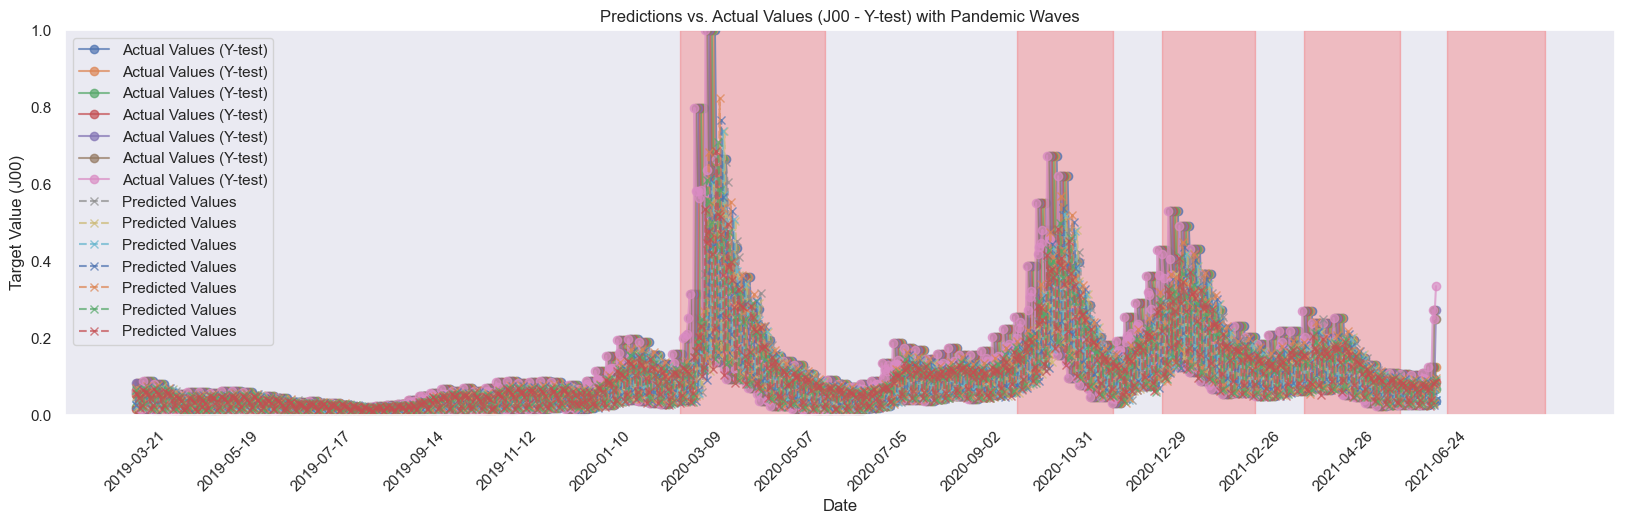

In [55]:
# Call the function with formatted dates
plot_predictions_with_waves(Y_test, predictions, date_list, df_waves)

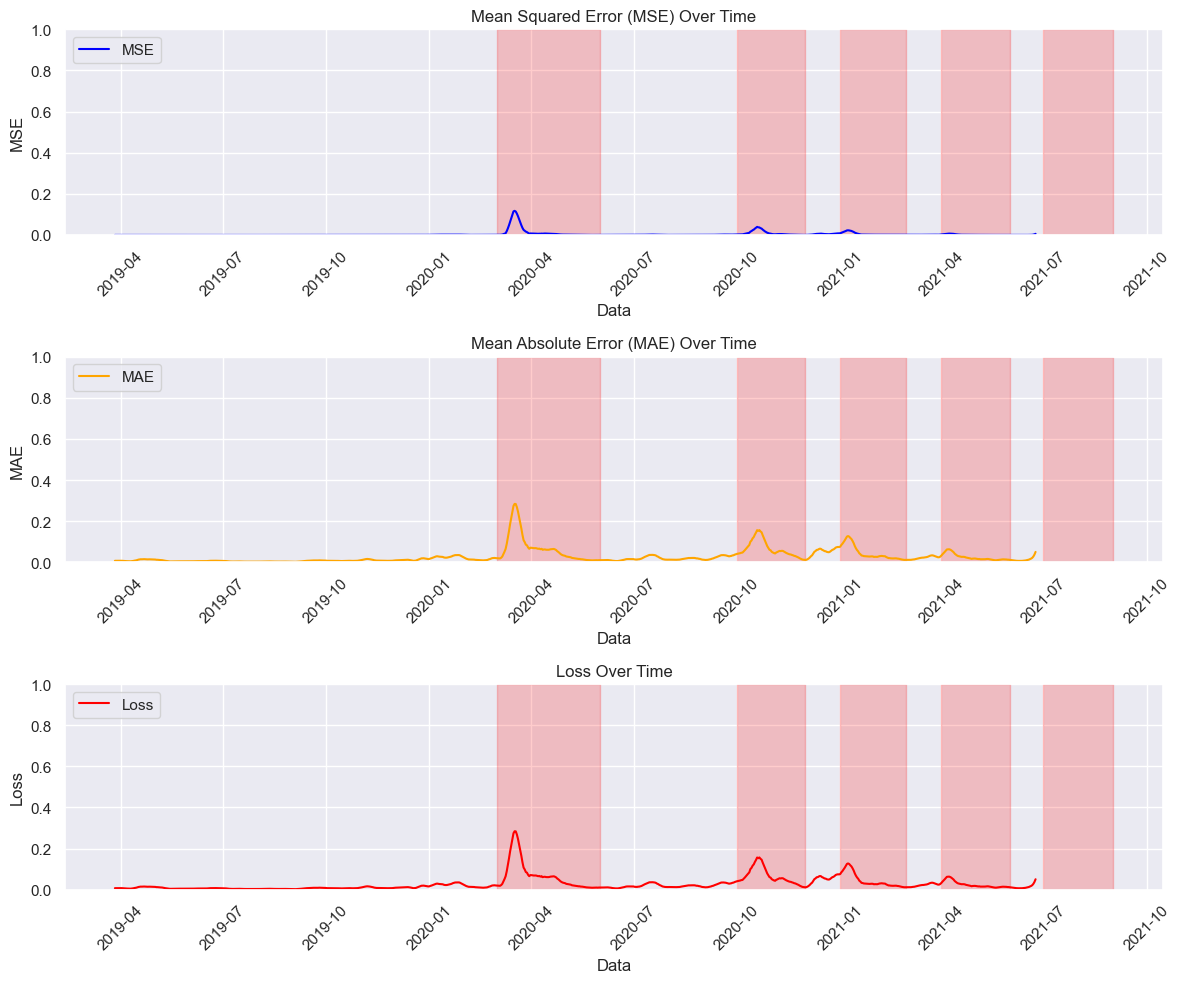

In [56]:
evaluate_model(model, X_test, Y_test, date_list, df_waves, sliding_window=forecast)